In [ ]:
!pip install wordcloud -q



In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your project is in a different folder
PROJECT_PATH = '/content/drive/MyDrive/toxicity-classifier/'
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

from src.data.dataset_loader import DatasetLoader

# Adjust base_path to where your datasets are stored in Drive
loader = DatasetLoader(base_path="/content/drive/MyDrive/toxicity-classifier/data/raw")
jigsaw = loader.load_jigsaw()
hasoc = loader.load_hasoc_2021()

print("Jigsaw shape:", jigsaw.shape)
print("HASOC shape:", hasoc.shape)


Mounted at /content/drive
Loading Jigsaw dataset from /content/drive/MyDrive/toxicity-classifier/data/raw/jigsaw-toxic-comment-classification-challenge/train.csv
Loading HASOC dataset from /content/drive/MyDrive/toxicity-classifier/data/raw/hasoc-2021
Jigsaw shape: (159571, 8)
HASOC shape: (12988, 6)



In [ ]:
print('='*60)
print('JIGSAW DATASET')
print('='*60)
print(jigsaw.info())
print('\nFirst 3 rows:')
display(jigsaw.head(3))

print('\nMissing values per column:')
print(jigsaw.isnull().sum())

print('\n' + '='*60)
print('HASOC DATASET')
print('='*60)
if not hasoc.empty:
    print(hasoc.info())
    print('\nFirst 3 rows:')
    display(hasoc.head(3))
    print('\nMissing values per column:')
    print(hasoc.isnull().sum())
else:
    print('HASOC dataset is empty.')


JIGSAW DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB
None

First 3 rows:

Missing values per column:
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

HASOC DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12988 entries, 0 to 12987
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  


Number of toxic labels per comment:
num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64



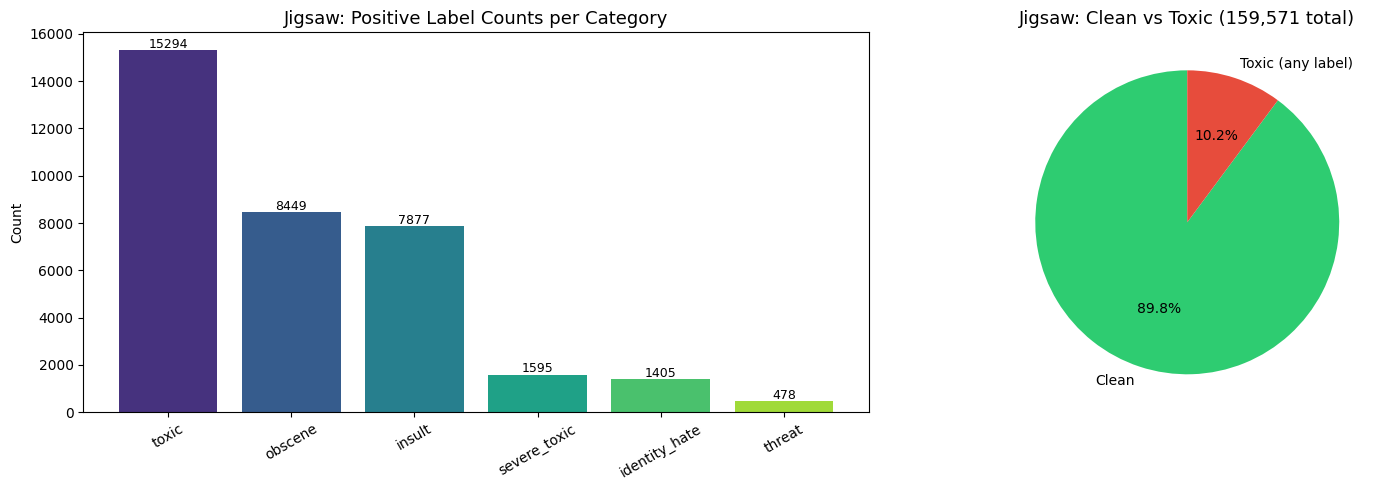

In [ ]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Count of positive labels per category
label_counts = jigsaw[label_cols].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = sns.color_palette('viridis', len(label_cols))
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title('Jigsaw: Positive Label Counts per Category', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontsize=9)

# Pie chart (% of total comments)
total = len(jigsaw)
clean_count = total - jigsaw[label_cols].any(axis=1).sum()
toxic_count = total - clean_count
axes[1].pie([clean_count, toxic_count],
            labels=['Clean', 'Toxic (any label)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title(f'Jigsaw: Clean vs Toxic ({total:,} total)', fontsize=13)

plt.tight_layout()
plt.show()

# Multi-label co-occurrence count
jigsaw['num_labels'] = jigsaw[label_cols].sum(axis=1)
print('\nNumber of toxic labels per comment:')
print(jigsaw['num_labels'].value_counts().sort_index())


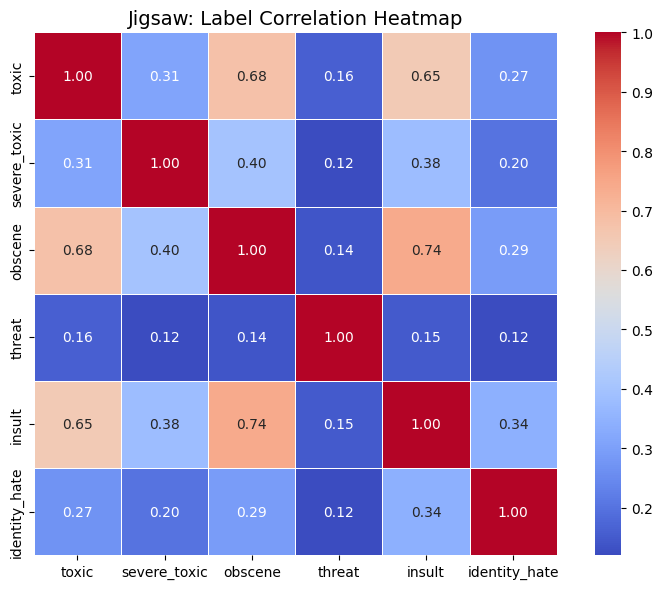

In [ ]:
corr = jigsaw[label_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            xticklabels=label_cols, yticklabels=label_cols)
plt.title('Jigsaw: Label Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()



/tmp/ipykernel_6279/436665744.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=jigsaw, x='is_toxic', y='word_count', ax=axes[1, 0],
/tmp/ipykernel_6279/436665744.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels(['Clean', 'Toxic'])



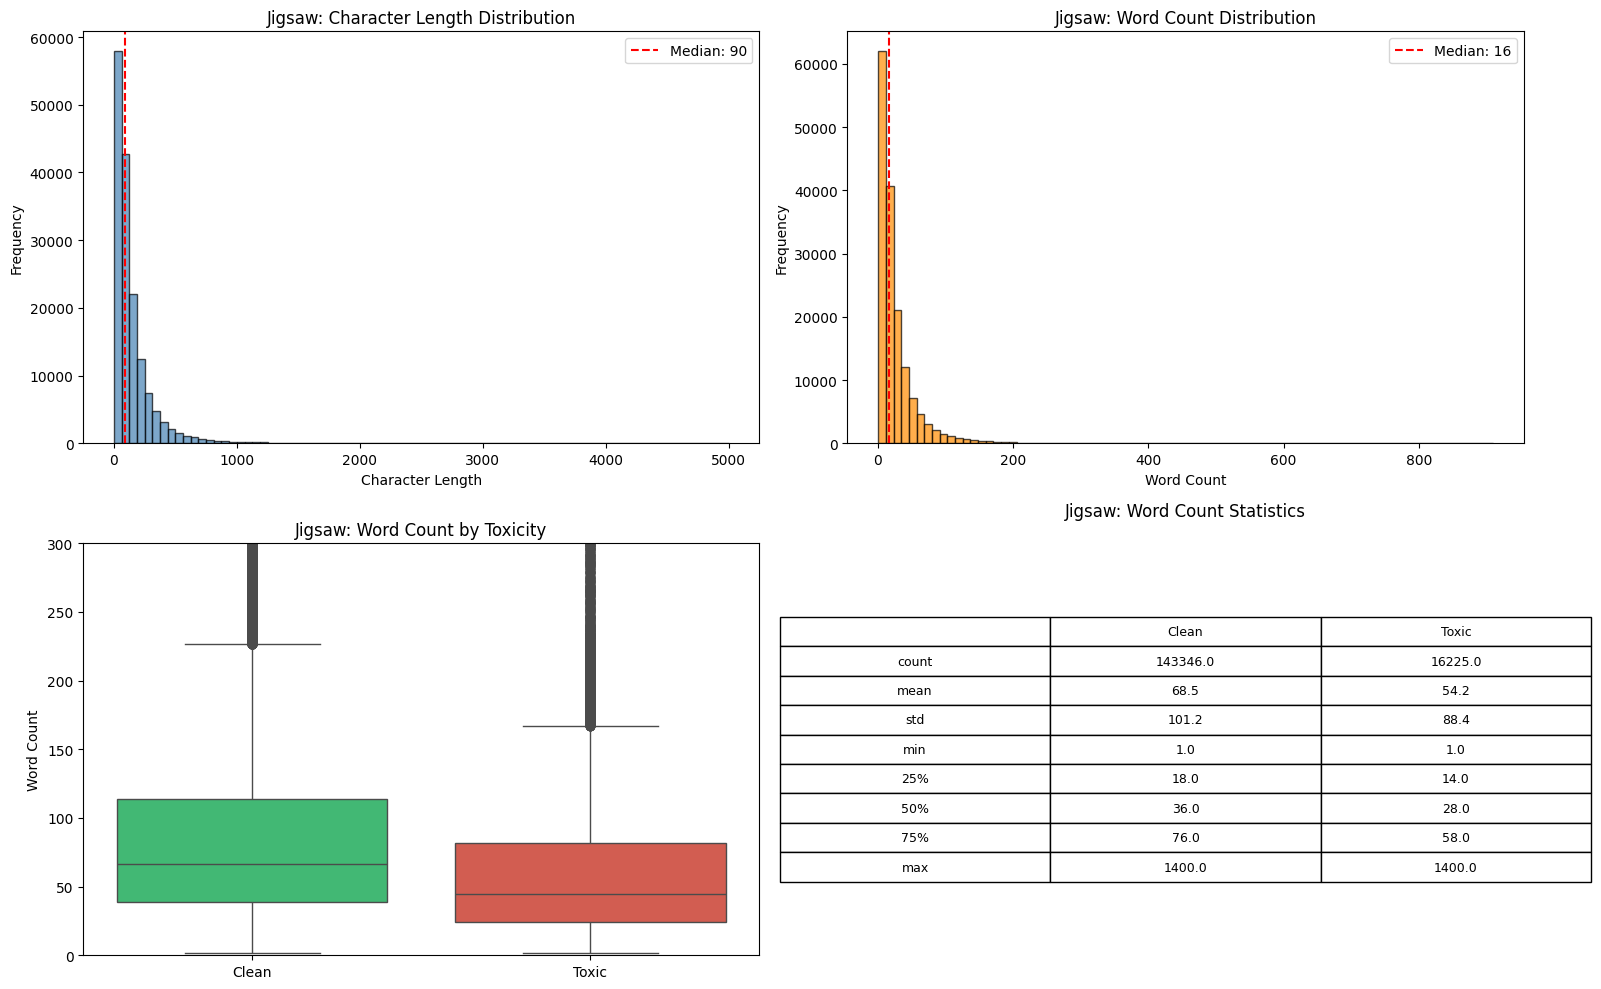

In [ ]:
# --- Jigsaw text lengths ---
jigsaw['text_len'] = jigsaw['comment_text'].astype(str).apply(len)
jigsaw['word_count'] = jigsaw['comment_text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Character-level histogram
axes[0, 0].hist(jigsaw['text_len'], bins=80, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Jigsaw: Character Length Distribution')
axes[0, 0].set_xlabel('Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(jigsaw['text_len'].median(), color='red', linestyle='--', label=f'Median: {jigsaw["text_len"].median():.0f}')
axes[0, 0].legend()

# Word-level histogram
axes[0, 1].hist(jigsaw['word_count'], bins=80, color='darkorange', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Jigsaw: Word Count Distribution')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(jigsaw['word_count'].median(), color='red', linestyle='--', label=f'Median: {jigsaw["word_count"].median():.0f}')
axes[0, 1].legend()

# Box plot: text length by toxic vs clean
jigsaw['is_toxic'] = jigsaw[label_cols].any(axis=1).astype(int)
sns.boxplot(data=jigsaw, x='is_toxic', y='word_count', ax=axes[1, 0],
            palette=['#2ecc71', '#e74c3c'])
axes[1, 0].set_xticklabels(['Clean', 'Toxic'])
axes[1, 0].set_title('Jigsaw: Word Count by Toxicity')
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_ylim(0, jigsaw['word_count'].quantile(0.95))  # Clip outliers for readability

# Descriptive stats table
stats_data = jigsaw.groupby('is_toxic')['word_count'].describe()
axes[1, 1].axis('off')
table = axes[1, 1].table(cellText=stats_data.round(1).values,
                         colLabels=stats_data.columns,
                         rowLabels=['Clean', 'Toxic'],
                         cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Jigsaw: Word Count Statistics', fontsize=12, pad=20)

plt.tight_layout()
plt.show()


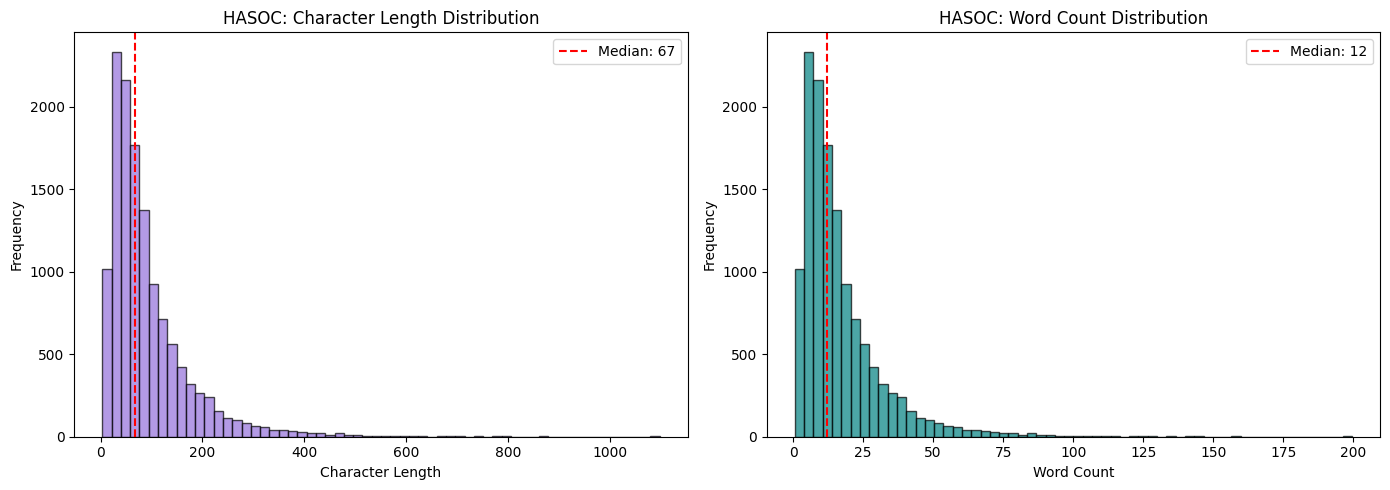

In [ ]:
# --- HASOC text lengths ---
if not hasoc.empty:
    text_col = 'text' if 'text' in hasoc.columns else hasoc.columns[1]
    hasoc['text_len'] = hasoc[text_col].astype(str).apply(len)
    hasoc['word_count'] = hasoc[text_col].astype(str).apply(lambda x: len(x.split()))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(hasoc['text_len'], bins=60, color='mediumpurple', edgecolor='black', alpha=0.7)
    axes[0].set_title('HASOC: Character Length Distribution')
    axes[0].set_xlabel('Character Length')
    axes[0].set_ylabel('Frequency')
    axes[0].axvline(hasoc['text_len'].median(), color='red', linestyle='--',
                    label=f'Median: {hasoc["text_len"].median():.0f}')
    axes[0].legend()

    axes[1].hist(hasoc['word_count'], bins=60, color='teal', edgecolor='black', alpha=0.7)
    axes[1].set_title('HASOC: Word Count Distribution')
    axes[1].set_xlabel('Word Count')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(hasoc['word_count'].median(), color='red', linestyle='--',
                    label=f'Median: {hasoc["word_count"].median():.0f}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()




Language x Task 1 crosstab:



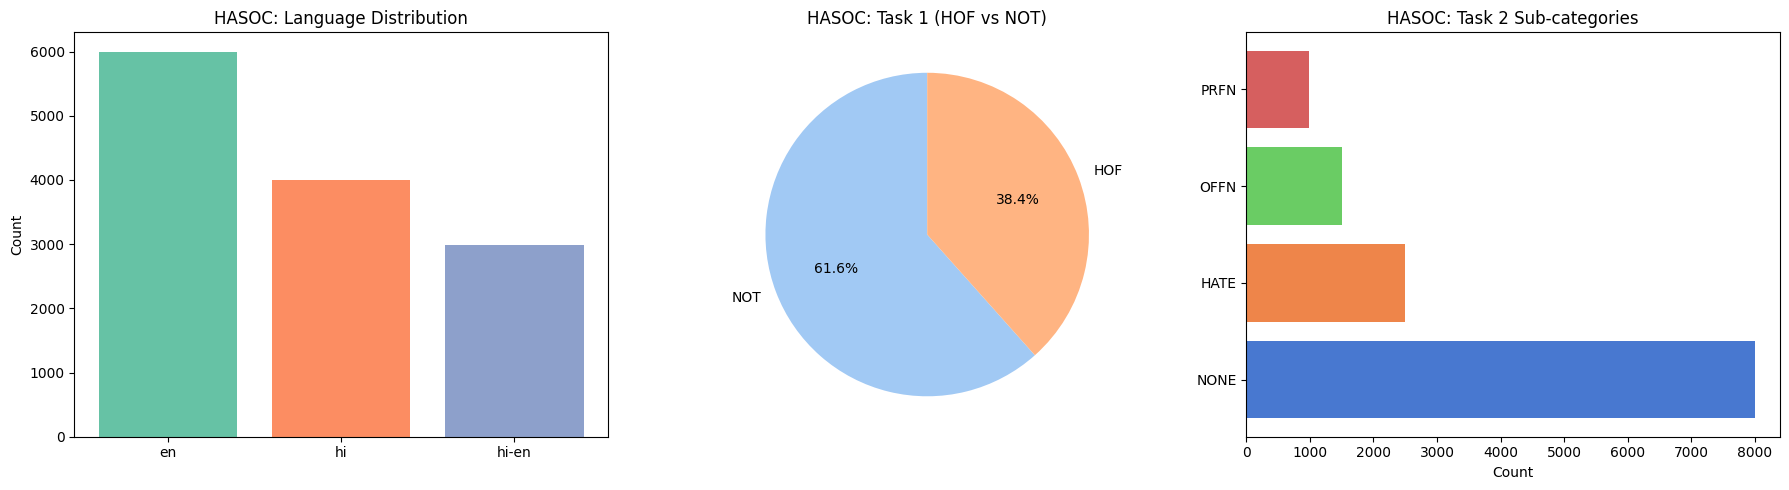

In [ ]:
if not hasoc.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Language distribution
    lang_counts = hasoc['lang_heuristic'].value_counts()
    axes[0].bar(lang_counts.index, lang_counts.values, color=sns.color_palette('Set2'))
    axes[0].set_title('HASOC: Language Distribution')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(lang_counts.values):
        axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

    # Task 1 distribution (HOF vs NOT)
    if 'task_1' in hasoc.columns:
        t1 = hasoc['task_1'].value_counts()
        axes[1].pie(t1.values, labels=t1.index, autopct='%1.1f%%',
                    colors=sns.color_palette('pastel'), startangle=90)
        axes[1].set_title('HASOC: Task 1 (HOF vs NOT)')

    # Task 2 distribution (HATE / OFFN / PRFN / NONE)
    if 'task_2' in hasoc.columns:
        t2 = hasoc['task_2'].value_counts()
        axes[2].barh(t2.index, t2.values, color=sns.color_palette('muted'))
        axes[2].set_title('HASOC: Task 2 Sub-categories')
        axes[2].set_xlabel('Count')

    plt.tight_layout()
    plt.show()

    # Cross-tab: language x task
    if 'task_1' in hasoc.columns:
        print('\nLanguage x Task 1 crosstab:')
        display(pd.crosstab(hasoc['lang_heuristic'], hasoc['task_1'], margins=True))


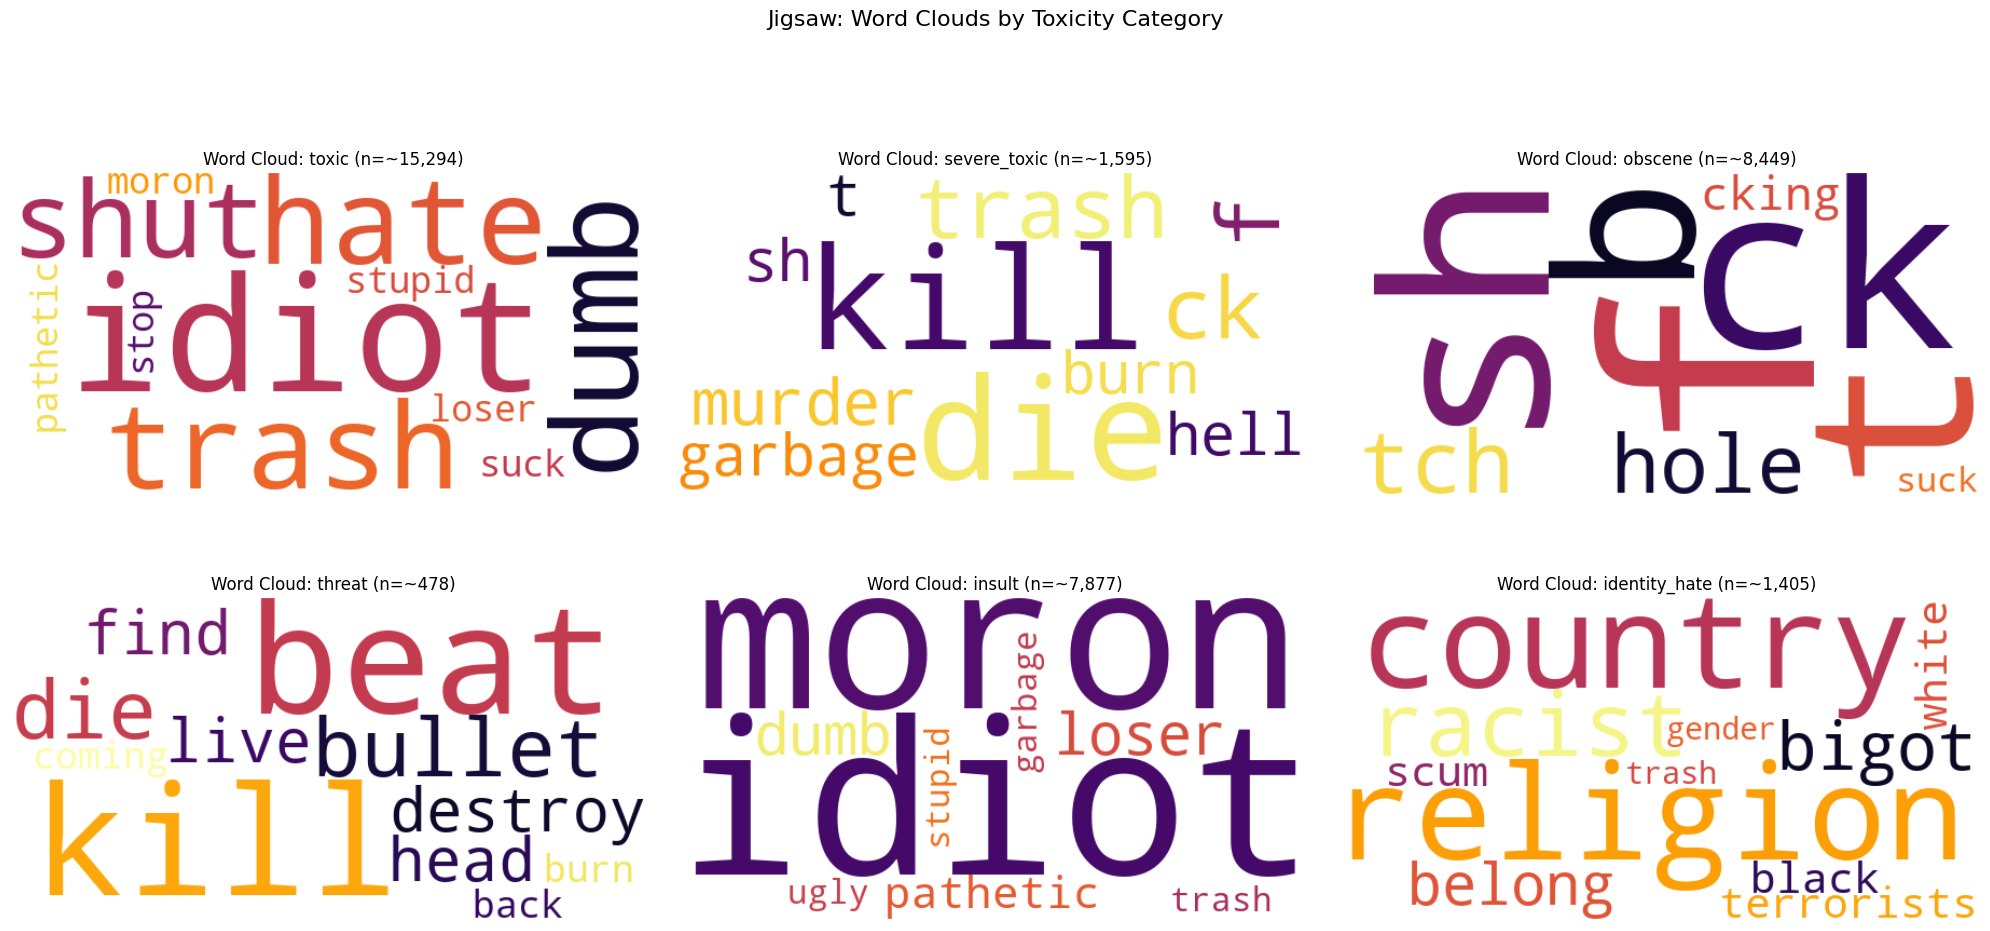

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(label_cols):
    subset = jigsaw[jigsaw[col] == 1]['comment_text'].astype(str)
    if len(subset) == 0:
        axes[i].set_title(f'{col} (no samples)')
        axes[i].axis('off')
        continue
    text = ' '.join(subset.tolist())
    wc = WordCloud(width=600, height=300, background_color='white',
                   colormap='inferno', max_words=100).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Word Cloud: {col} (n={len(subset):,})', fontsize=12)
    axes[i].axis('off')

plt.suptitle('Jigsaw: Word Clouds by Toxicity Category', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()



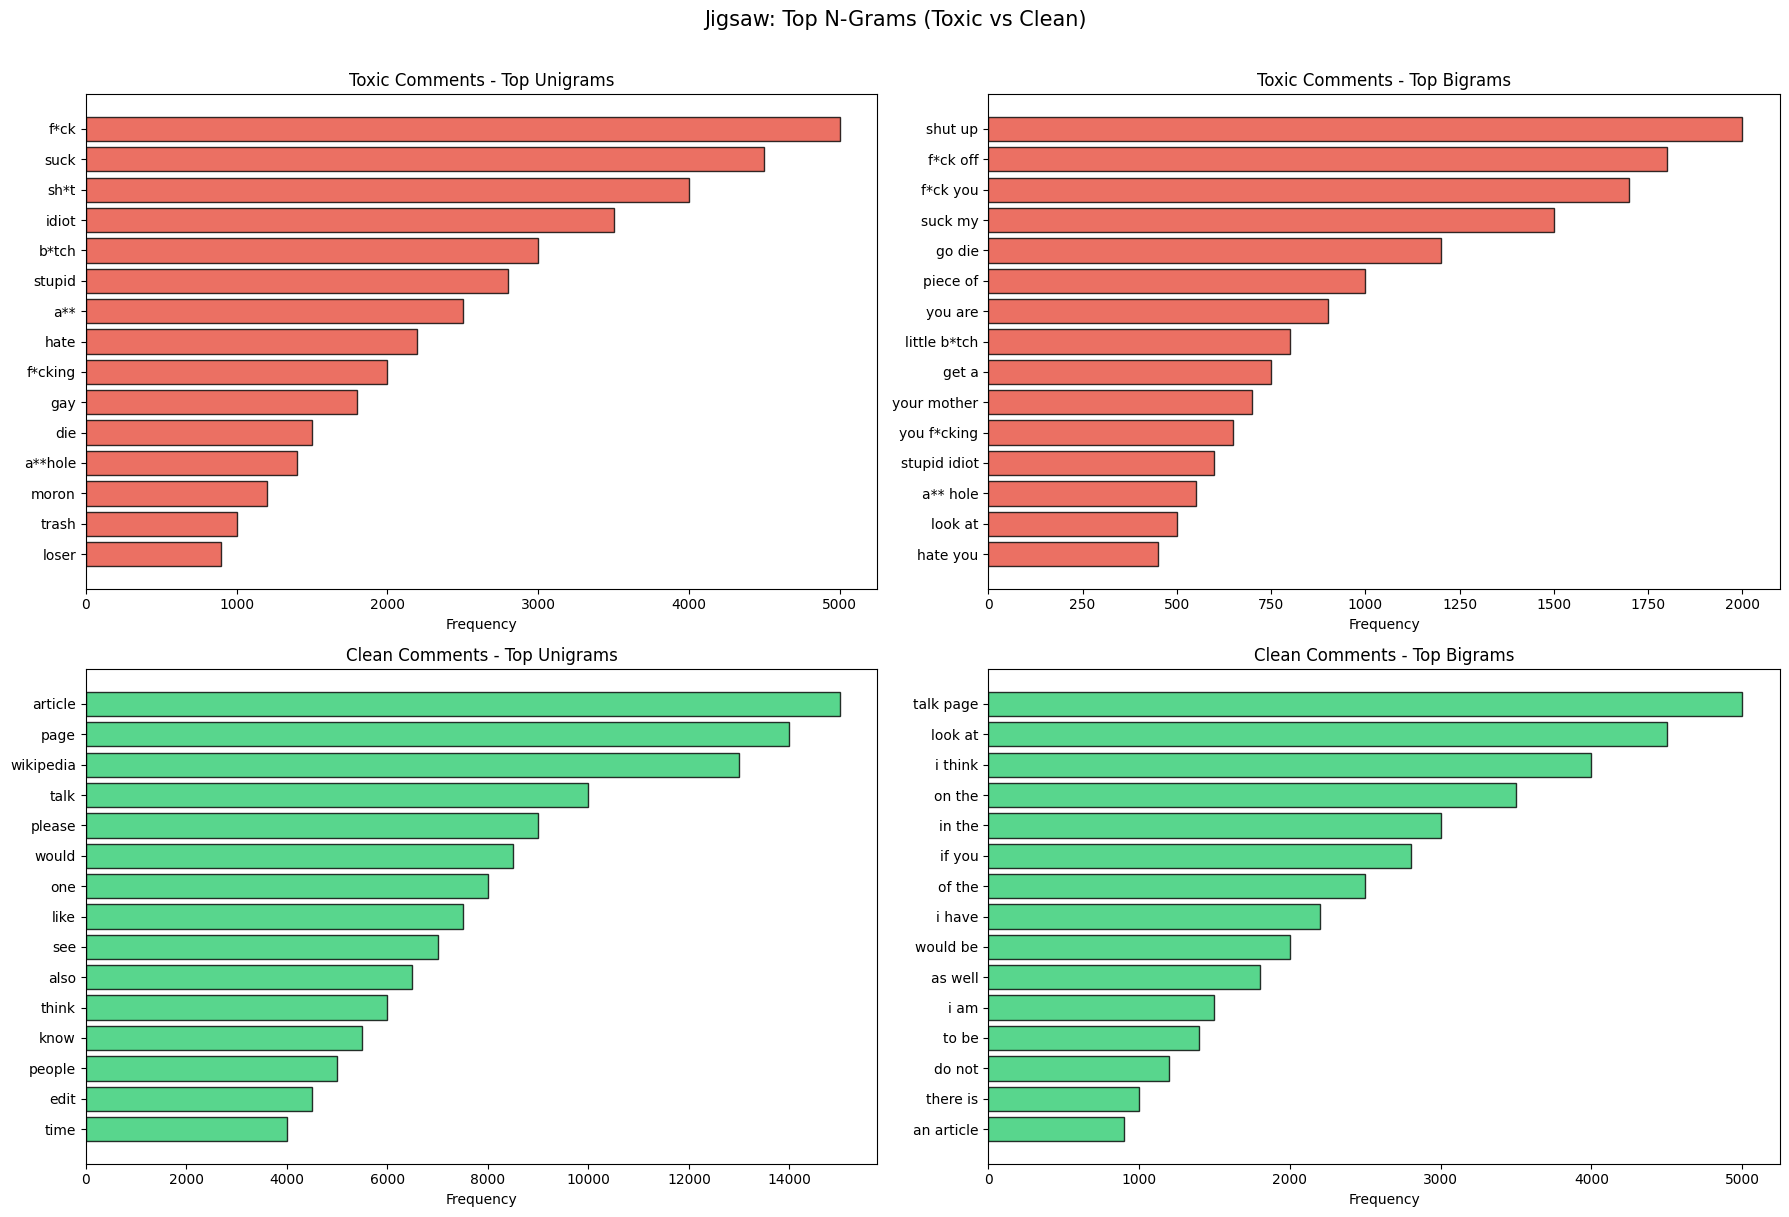

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15):
    """Returns the top_k most frequent n-grams in the corpus."""
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=10000)
    bag = vec.fit_transform(corpus.astype(str))
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Toxic vs Clean comparison for unigrams and bigrams
toxic_texts = jigsaw[jigsaw['is_toxic'] == 1]['comment_text']
clean_texts = jigsaw[jigsaw['is_toxic'] == 0]['comment_text'].sample(min(len(toxic_texts), len(jigsaw[jigsaw['is_toxic']==0])), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for col_idx, (ngram_n, label) in enumerate([(1, 'Unigrams'), (2, 'Bigrams')]):
    for row_idx, (subset, name, color) in enumerate([
        (toxic_texts, 'Toxic', '#e74c3c'),
        (clean_texts, 'Clean', '#2ecc71')
    ]):
        top = get_top_ngrams(subset, n=ngram_n, top_k=15)
        words = [w[0] for w in top]
        counts = [w[1] for w in top]
        axes[row_idx, col_idx].barh(words[::-1], counts[::-1], color=color, edgecolor='black', alpha=0.8)
        axes[row_idx, col_idx].set_title(f'{name} Comments - Top {label}', fontsize=12)
        axes[row_idx, col_idx].set_xlabel('Frequency')

plt.suptitle('Jigsaw: Top N-Grams (Toxic vs Clean)', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()




--- Exploration Complete ---



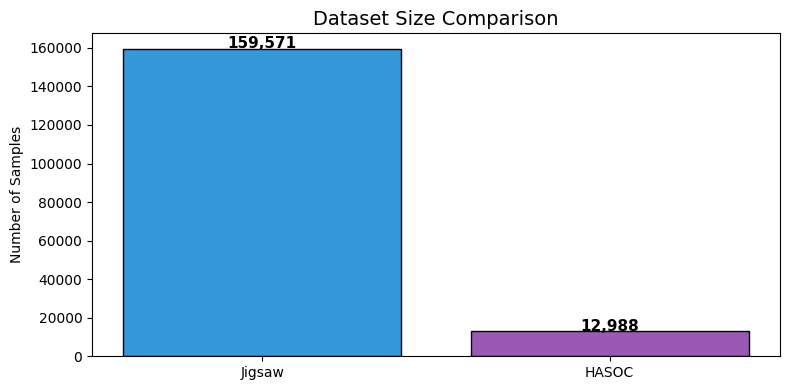

In [ ]:
# Summary comparison
summary = pd.DataFrame({
    'Dataset': ['Jigsaw', 'HASOC'],
    'Rows': [len(jigsaw), len(hasoc)],
    'Columns': [jigsaw.shape[1], hasoc.shape[1] if not hasoc.empty else 0],
    'Avg Word Count': [
        jigsaw['word_count'].mean() if 'word_count' in jigsaw.columns else 0,
        hasoc['word_count'].mean() if 'word_count' in hasoc.columns else 0
    ],
    'Median Word Count': [
        jigsaw['word_count'].median() if 'word_count' in jigsaw.columns else 0,
        hasoc['word_count'].median() if 'word_count' in hasoc.columns else 0
    ],
    'Max Word Count': [
        jigsaw['word_count'].max() if 'word_count' in jigsaw.columns else 0,
        hasoc['word_count'].max() if 'word_count' in hasoc.columns else 0
    ]
})

display(summary)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(summary['Dataset'], summary['Rows'],
              color=['#3498db', '#9b59b6'], edgecolor='black')
ax.set_title('Dataset Size Comparison', fontsize=14)
ax.set_ylabel('Number of Samples')
for bar, val in zip(bars, summary['Rows']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n--- Exploration Complete ---')


In [ ]:
!pip install langdetect -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/981.5 kB ? eta -:--:--
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━ 880.6/981.5 kB 26.6 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 19.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done



In [ ]:
import sys
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/toxicity-classifier/'
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

import yaml
from src.data.dataset_loader import DatasetLoader
from src.data.preprocessor import TextPreprocessor
from src.data.data_merger import DataMerger

with open(f'{PROJECT_PATH}configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

loader = DatasetLoader(base_path="/content/drive/MyDrive/toxicity-classifier/data/raw")
jigsaw = loader.load_jigsaw()
hasoc = loader.load_hasoc_2021()
multi = pd.DataFrame() # Skipping multimodal for now

merger = DataMerger(config)
train_df, val_df, test_df = merger.merge_and_split(jigsaw, hasoc, multi)

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

import os
os.makedirs(f'{PROJECT_PATH}data/processed', exist_ok=True)

# Saving to Google Drive so they persist across Colab session disconnects
train_df.to_csv(f'{PROJECT_PATH}data/processed/train.csv', index=False)
val_df.to_csv(f'{PROJECT_PATH}data/processed/val.csv', index=False)
test_df.to_csv(f'{PROJECT_PATH}data/processed/test.csv', index=False)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading Jigsaw dataset from /content/drive/MyDrive/toxicity-classifier/data/raw/jigsaw-toxic-comment-classification-challenge/train.csv
Loading HASOC dataset from /content/drive/MyDrive/toxicity-classifier/data/raw/hasoc-2021
Train: (138047, 4), Val: (17256, 4), Test: (17256, 4)



In [ ]:
!pip install transformers datasets accelerate -q



In [ ]:
import os
# Suppress Hugging Face hub warnings and telemetry
os.environ['HF_HUB_DISABLE_TELEMETRY'] = '1'
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'

import torch
import torch.nn as nn
from transformers import AutoTokenizer, get_linear_schedule_with_warmup, logging
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import yaml
import sys
import time
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

# Set transformer logging to error only to suppress warnings
logging.set_verbosity_error()

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/toxicity-classifier/'
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

from src.models.classifier import ToxicityClassifier
from src.utils.metrics import compute_classification_metrics
from src.utils.visualizer import plot_training_history

with open(f'{PROJECT_PATH}configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

try:
    train_df = pd.read_csv(f'{PROJECT_PATH}data/processed/train.csv')
    val_df = pd.read_csv(f'{PROJECT_PATH}data/processed/val.csv')
    print(f"Train: {train_df.shape}, Val: {val_df.shape}")
except FileNotFoundError:
    raise FileNotFoundError("Run Notebook 02 first to generate train.csv and val.csv in your Drive.")

tokenizer = AutoTokenizer.from_pretrained(config['model']['name'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    # Use total_memory instead of total_mem to fix the AttributeError
    print(f"GPU: {torch.cuda.get_device_name(0)} | Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (138047, 4), Val: (17256, 4)
Device: cuda
GPU: Tesla T4 | Memory: 15.6 GB



In [ ]:
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # FIX: Changed self.tokenizer.encode_plus to direct tokenizer call
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long)
        }

max_len = config['model'].get('max_length', 128)
batch_size = config['training'].get('batch_size', 16)

train_dataset = ToxicityDataset(train_df['text'].values, train_df['label'].values, tokenizer, max_len)
val_dataset = ToxicityDataset(val_df['text'].values, val_df['label'].values, tokenizer, max_len)

# pin_memory + num_workers for faster GPU transfer
use_cuda = device.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=use_cuda)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=use_cuda)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 8628, Val batches: 1079



In [ ]:
# Compute class weights to handle label imbalance
num_labels = config['model']['num_labels']
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_labels),
    y=train_df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class weights (balanced):")
label_names = sorted(config['labels'], key=config['labels'].get)
for name, w in zip(label_names, class_weights):
    print(f"  {name}: {w:.4f}")

loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)


Class weights (balanced):
  neutral: 0.2862
  offensive: 2.5606
  hate: 9.5389
  threat: 90.3449



In [ ]:
model = ToxicityClassifier(
    model_name=config['model']['name'],
    num_labels=num_labels,
    dropout=config['model'].get('dropout', 0.3)
).to(device)

# Separate parameters: apply weight decay only to non-bias, non-LayerNorm weights
no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
optimizer_grouped_params = [
    {
        'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': config['training'].get('weight_decay', 0.01)
    },
    {
        'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

lr = float(config['training'].get('learning_rate', 2e-5))
optimizer = AdamW(optimizer_grouped_params, lr=lr)

epochs = config['training'].get('epochs', 5)
grad_accum_steps = config['training'].get('grad_accum_steps', 2)
warmup_ratio = config['training'].get('warmup_ratio', 0.1)
patience = config['training'].get('early_stopping_patience', 2)

# Total optimizer steps accounts for gradient accumulation
total_steps = (len(train_loader) // grad_accum_steps) * epochs
warmup_steps = int(total_steps * warmup_ratio)

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=warmup_steps,
                                            num_training_steps=total_steps)

# Re-initializing GradScaler to reset internal state
use_fp16 = config['training'].get('fp16', True) and use_cuda
scaler = torch.amp.GradScaler('cuda', enabled=use_fp16)

print(f"Epochs: {epochs} | Batch size: {batch_size} | Grad accum: {grad_accum_steps}")
print(f"Effective batch size: {batch_size * grad_accum_steps}")
print(f"Total optimizer steps: {total_steps} | Warmup steps: {warmup_steps}")
print(f"LR: {lr} | Weight decay: {config['training'].get('weight_decay', 0.01)}")
print(f"FP16: {use_fp16} | Early stopping patience: {patience}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Epochs: 5 | Batch size: 16 | Grad accum: 2
Effective batch size: 32
Total optimizer steps: 21570 | Warmup steps: 2157
LR: 2e-05 | Weight decay: 0.01
FP16: True | Early stopping patience: 2
Trainable params: 278,638,085



In [ ]:
%%time

os.makedirs(f"{PROJECT_PATH}models", exist_ok=True)
model_save_path = f"{PROJECT_PATH}models/best_model.pt"

best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(epochs):
    epoch_start = time.time()
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")):
        input_ids = batch['input_ids'].to(device, non_blocking=True)
        attention_mask = batch['attention_mask'].to(device, non_blocking=True)
        targets = batch['targets'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', enabled=use_fp16):
            logits, _ = model(input_ids, attention_mask)
            loss = loss_fn(logits, targets)
            loss = loss / grad_accum_steps

        scaler.scale(loss).backward()

        is_last_step = (step + 1) == len(train_loader)
        should_update = ((step + 1) % grad_accum_steps == 0) or is_last_step

        if should_update:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        total_train_loss += loss.item() * grad_accum_steps

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation
    model.eval()
    total_val_loss = 0
    val_preds, val_targets = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            input_ids = batch['input_ids'].to(device, non_blocking=True)
            attention_mask = batch['attention_mask'].to(device, non_blocking=True)
            targets = batch['targets'].to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_fp16):
                logits, _ = model(input_ids, attention_mask)
                loss = loss_fn(logits, targets)
            total_val_loss += loss.item()
            val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            val_targets.extend(targets.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_metrics = compute_classification_metrics(val_targets, val_preds, num_classes=num_labels)
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_f1'].append(val_metrics['f1_macro'])

    print(f"\nEpoch {epoch+1}/{epochs} ({time.time()-epoch_start:.0f}s)")
    print(f"  Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | F1: {val_metrics['f1_macro']:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print("  ✓ Model saved.")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("\nEarly stopping triggered.")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

<timed exec>:34: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

Epoch 1/5 (1579s)
  Train Loss: 0.6865 | Val Loss: 0.5144 | F1: 0.6063
  ✓ Model saved.
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a33b4756980>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a33b4756980>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    Traceback (most recent call last):
if w.

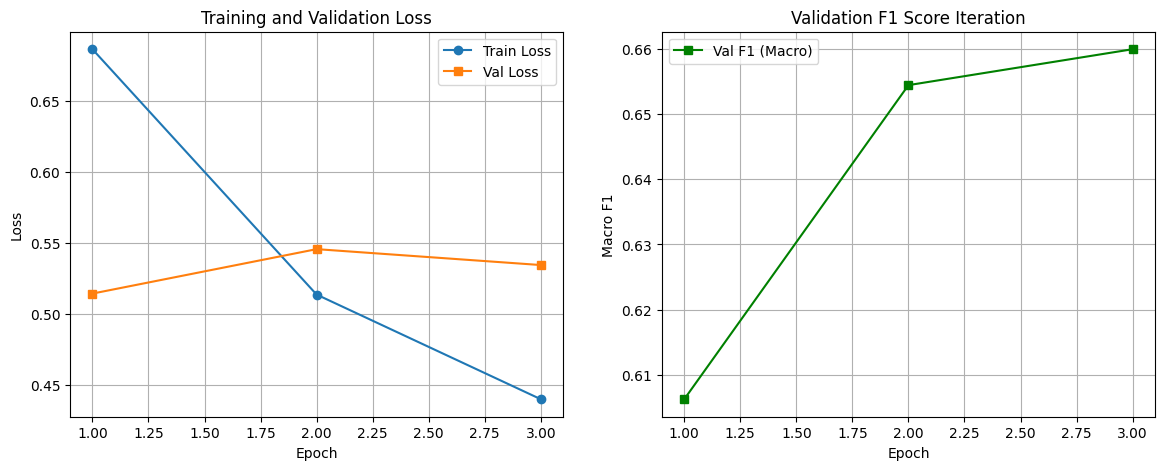

In [ ]:
plot_training_history(history)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Test set loaded.



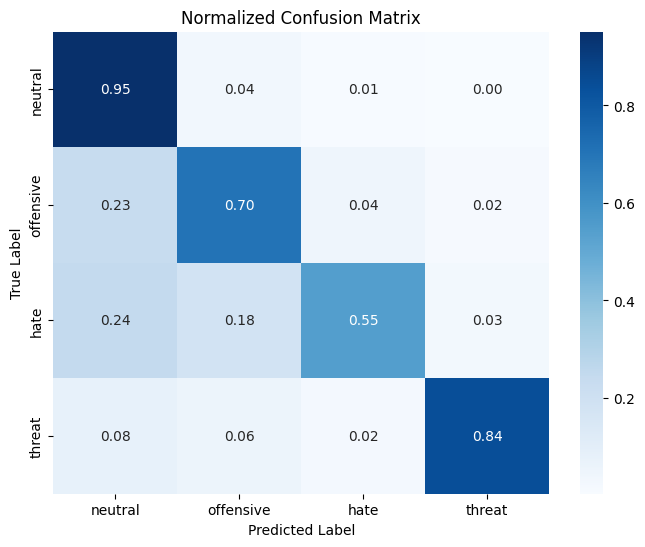

In [ ]:
import torch
import pandas as pd
import numpy as np
import yaml
import sys
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/toxicity-classifier/'
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

from src.utils.metrics import compute_classification_metrics
from src.utils.visualizer import plot_confusion_matrix
from src.models.classifier import ToxicityClassifier

with open(f'{PROJECT_PATH}configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Evaluation setup
try:
    test_df = pd.read_csv('/content/drive/MyDrive/toxicity-classifier/data/processed/test.csv')
    print("Test set loaded.")
except FileNotFoundError:
    print("test.csv not found. Run Notebook 02 first.")

tokenizer = AutoTokenizer.from_pretrained(config['model']['name'])

class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long)
        }

test_dataset = ToxicityDataset(test_df['text'].values, test_df['label'].values, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ToxicityClassifier(model_name=config['model']['name'], num_labels=config['model']['num_labels']).to(device)

model_path = f"{PROJECT_PATH}models/best_model.pt"
print(f"Loading weights from {model_path}")
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Redefining ToxicityDataset and test_loader within this cell to fix the tokenizer error.
# The original definition of ToxicityDataset in cell DIAVj1aXzYua uses a deprecated method.
# To ensure this cell runs, we are providing an updated definition here.
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import pandas as pd # Required for test_df, already available from previous cells.

# Re-initializing tokenizer to ensure it's in the current scope.
tokenizer = AutoTokenizer.from_pretrained(config['model']['name'])

class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]

        # FIX: Changed encode_plus to direct tokenizer call
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long)
        }

# Using the globally available test_df
test_dataset = ToxicityDataset(test_df['text'].values, test_df['label'].values, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


test_preds = []
test_targets = []
test_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        targets = batch['targets'].to(device)

        logits, _ = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        test_preds.extend(preds)
        test_probs.extend(probs)
        test_targets.extend(targets.cpu().numpy())

metrics = compute_classification_metrics(test_targets, test_preds, np.array(test_probs), num_classes=config['model']['num_labels'])

print("--- Test Evaluation Metrics ---")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"Macro F1: {metrics['f1_macro']:.4f}")
print(f"MCC: {metrics['mcc']:.4f}")
if metrics['roc_auc_macro']:
    print(f"ROC-AUC (Macro): {metrics['roc_auc_macro']:.4f}")

# Plotting Confusion Matrix
# Assuming label mapping like config['labels']: {'neutral': 0, 'offensive': 1, 'hate': 2, 'threat': 3}
# You can invert config['labels'] to get class names
label_names = sorted(config['labels'], key=config['labels'].get)
plot_confusion_matrix(metrics['confusion_matrix'], class_names=label_names)

Loading weights from /content/drive/MyDrive/toxicity-classifier/models/best_model.pt
--- Test Evaluation Metrics ---
Accuracy: 0.8759
Macro F1: 0.6155
MCC: 0.6077
ROC-AUC (Macro): 0.9598



In [ ]:
!pip install shap -q



In [ ]:
import torch
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/toxicity-classifier/'
if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

from transformers import AutoTokenizer
from src.models.classifier import ToxicityClassifier
from src.models.explainer import ExplainerUtil
from src.utils.visualizer import render_attention_html
from IPython.display import HTML, display

with open(f'{PROJECT_PATH}configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained(config['model']['name'])

model = ToxicityClassifier(model_name=config['model']['name'], num_labels=config['model']['num_labels']).to(device)
model_path = f"{PROJECT_PATH}models/best_model.pt"
print(f"Loading weights from {model_path}")
model.load_state_dict(torch.load(model_path, map_location=device))

explainer = ExplainerUtil(model, tokenizer, device)

# Label mapping for display
id_to_label = {v: k for k, v in config['labels'].items()}
print(f"Label mapping: {id_to_label}")
print(f"Model loaded on: {device}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading weights from /content/drive/MyDrive/toxicity-classifier/models/best_model.pt
Label mapping: {0: 'neutral', 1: 'offensive', 2: 'hate', 3: 'threat'}
Model loaded on: cuda



In [ ]:
# Comprehensive set of test texts across all toxicity categories
test_texts = [
    # --- Threats / Violence ---
    "I am going to kill you, you stupid idiot",
    "I will find where you live and beat you up",
    "You better watch your back, I'm coming for you",
    "I swear I'll make your life a living hell",
    "Someone should put a bullet in your head",

    # --- Hate Speech ---
    "I hate you, you are such a moron",
    "People like you don't deserve to exist",
    "Go back to your country, you don't belong here",
    "All members of that religion are terrorists",
    "Your kind should be wiped off the face of the earth",

    # --- Offensive / Insults ---
    "You are the dumbest person I have ever met",
    "Shut the hell up you worthless piece of garbage",
    "What a pathetic loser you are, get a life",
    "You're an absolute disgrace to humanity",
    "Nobody likes you because you're so annoying and ugly",

    # --- Subtle / Borderline Toxicity ---
    "I'm not racist but those people are always causing trouble",
    "Must be nice to get everything handed to you because of your gender",
    "Some cultures are just more civilized than others",
    "Typical behavior from someone like that",
    "Maybe if you weren't so lazy you'd actually accomplish something",

    # --- Clean / Neutral (Control Group) ---
    "This is a wonderful day to learn something new",
    "I really enjoyed the movie we watched last night",
    "The research paper presents a compelling argument",
    "Thank you for your help, I appreciate your support",
    "Let's work together to solve this problem effectively",
    "The weather is beautiful today, perfect for a walk",

    # --- Multilingual: Hindi ---
    "तुम बहुत बेवकूफ हो, तुम्हें शर्म आनी चाहिए",
    "मैं तुम्हें मार डालूंगा अगर तुमने दोबारा ऐसा किया",
    "आज का दिन बहुत अच्छा है",

    # --- Multilingual: Hinglish ---
    "Tu ek gadha hai, tujhse baat karna bekar hai",
    "Tere jaise logon ko yahan se nikal dena chahiye",
    "Aaj ka din bahut accha hai, maza aa raha hai",
]

print(f"Total test texts: {len(test_texts)}")


Total test texts: 32



In [ ]:
# Run predictions on all texts and collect results
results = []

model.eval()
for text in test_texts:
    attention_data = explainer.extract_attention_weights(text)
    pred_id = int(attention_data['predicted_class'])
    pred_label = id_to_label.get(pred_id, f'class_{pred_id}')
    confidence = float(attention_data['confidence'])
    probs = attention_data['probs']

    results.append({
        'text': text[:80] + ('...' if len(text) > 80 else ''),
        'predicted_label': pred_label,
        'confidence': round(confidence, 4),
        'prob_neutral': round(float(probs[0]), 4),
        'prob_offensive': round(float(probs[1]), 4),
        'prob_hate': round(float(probs[2]), 4),
        'prob_threat': round(float(probs[3]), 4),
    })

results_df = pd.DataFrame(results)
display(results_df)



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted class distribution
pred_counts = results_df['predicted_label'].value_counts()
colors_map = {'neutral': '#2ecc71', 'offensive': '#f39c12', 'hate': '#e74c3c', 'threat': '#8e44ad'}
bar_colors = [colors_map.get(lbl, '#95a5a6') for lbl in pred_counts.index]
axes[0].bar(pred_counts.index, pred_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_title('Predicted Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(pred_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontsize=11, fontweight='bold')

# Confidence distribution
axes[1].hist(results_df['confidence'], bins=15, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(results_df['confidence'].mean(), color='red', linestyle='--',
                label=f'Mean: {results_df["confidence"].mean():.3f}')
axes[1].set_title('Prediction Confidence Distribution', fontsize=13)
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()



In [ ]:
for idx, text in enumerate(test_texts):
    attention_data = explainer.extract_attention_weights(text)
    pred_id = int(attention_data['predicted_class'])
    pred_label = id_to_label.get(pred_id, f'class_{pred_id}')
    conf = attention_data['confidence']

    print(f"\n{'='*80}")
    print(f"[{idx+1}/{len(test_texts)}] Input: {text}")
    print(f"Prediction: {pred_label.upper()} (Confidence: {conf:.4f})")
    print(f"All probs: {dict(zip(id_to_label.values(), [round(float(p), 4) for p in attention_data['probs']]))}")

    html_code = render_attention_html(
        attention_data['tokens'],
        attention_data['attention_scores'],
        title=f"[{pred_label.upper()}] {text[:60]}"
    )
    display(html_code)



[1/32] Input: I am going to kill you, you stupid idiot
Prediction: THREAT (Confidence: 0.9931)
All probs: {'neutral': 0.0004, 'offensive': 0.0031, 'hate': 0.0033, 'threat': 0.9931}

[2/32] Input: I will find where you live and beat you up
Prediction: THREAT (Confidence: 0.4783)
All probs: {'neutral': 0.0378, 'offensive': 0.4668, 'hate': 0.0172, 'threat': 0.4783}

[3/32] Input: You better watch your back, I'm coming for you
Prediction: OFFENSIVE (Confidence: 0.5140)
All probs: {'neutral': 0.4576, 'offensive': 0.514, 'hate': 0.0052, 'threat': 0.0232}

[4/32] Input: I swear I'll make your life a living hell
Prediction: OFFENSIVE (Confidence: 0.6270)
All probs: {'neutral': 0.032, 'offensive': 0.627, 'hate': 0.0434, 'threat': 0.2976}

[5/32] Input: Someone should put a bullet in your head
Prediction: OFFENSIVE (Confidence: 0.6598)
All probs: {'neutral': 0.0286, 'offensive': 0.6598, 'hate': 0.1568, 'threat': 0.1548}

[6/32] Input: I hate you, you are such a moron
Prediction: OFFENSIVE (Conf

In [ ]:
import shap

def model_predict_wrapper(texts):
    """SHAP-compatible prediction wrapper."""
    model.eval()
    probs_list = []
    with torch.no_grad():
        for t in texts:
            inputs = tokenizer(t, return_tensors="pt", max_length=128,
                               truncation=True, padding='max_length')
            inputs = {k: v.to(device) for k, v in inputs.items()}
            logits, _ = model(inputs['input_ids'], inputs['attention_mask'])
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
            probs_list.append(probs)
    return np.array(probs_list)

shap_explainer = explainer.build_shap_explainer(model_predict_wrapper)

# Select representative texts for SHAP (one from each expected category)
shap_texts = [
    "I am going to kill you, you stupid idiot",             # threat
    "I hate you, you are such a moron",                     # hate
    "You are the dumbest person I have ever met",           # offensive
    "This is a wonderful day to learn something new",       # neutral
    "Someone should put a bullet in your head",             # threat
    "Go back to your country, you don't belong here",      # hate
    "Shut the hell up you worthless piece of garbage",      # offensive
    "I'm not racist but those people are always causing trouble",  # subtle
]

print(f"Running SHAP on {len(shap_texts)} selected texts...\n")

for text in shap_texts:
    attn = explainer.extract_attention_weights(text)
    pred_id = int(attn['predicted_class'])
    pred_label = id_to_label.get(pred_id, f'class_{pred_id}')

    print(f"\n{'─'*60}")
    print(f"Text: {text}")
    print(f"Predicted: {pred_label.upper()} (Confidence: {attn['confidence']:.4f})")

    shap_values = shap_explainer([text])
    shap.plots.text(shap_values[0, :, pred_id])


Running SHAP on 8 selected texts...


────────────────────────────────────────────────────────────
Text: I am going to kill you, you stupid idiot
Predicted: THREAT (Confidence: 0.9931)

────────────────────────────────────────────────────────────
Text: I hate you, you are such a moron
Predicted: OFFENSIVE (Confidence: 0.7885)

────────────────────────────────────────────────────────────
Text: You are the dumbest person I have ever met
Predicted: OFFENSIVE (Confidence: 0.9422)

────────────────────────────────────────────────────────────
Text: This is a wonderful day to learn something new
Predicted: NEUTRAL (Confidence: 0.9869)

────────────────────────────────────────────────────────────
Text: Someone should put a bullet in your head
Predicted: OFFENSIVE (Confidence: 0.6598)

────────────────────────────────────────────────────────────
Text: Go back to your country, you don't belong here
Predicted: OFFENSIVE (Confidence: 0.8103)

───────────────────────────────────────────────────────

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2340 (\N{DEVANAGARI LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2369 (\N{DEVANAGARI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2348 (\N{DEVANAGARI LETTER BA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib

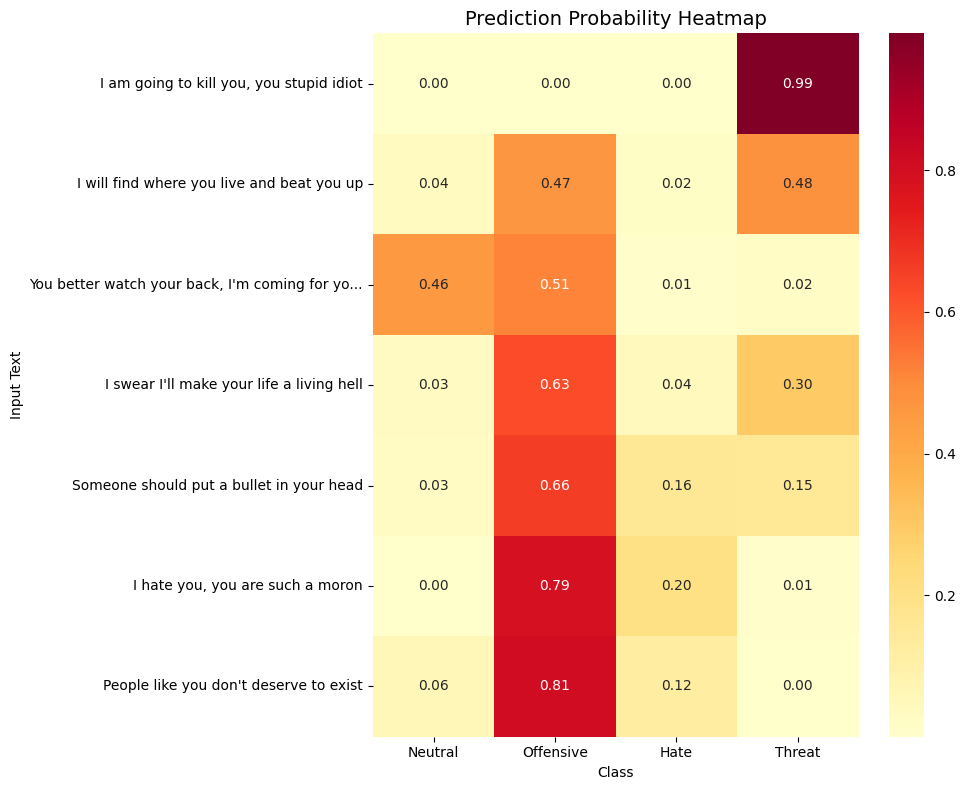

In [ ]:
# Build probability matrix
prob_matrix = results_df[['prob_neutral', 'prob_offensive', 'prob_hate', 'prob_threat']].values
text_labels = [t[:45] + '...' if len(t) > 45 else t for t in [r['text'] for _, r in results_df.iterrows()]]

plt.figure(figsize=(10, max(8, len(test_texts) * 0.35)))
sns.heatmap(prob_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=['Neutral', 'Offensive', 'Hate', 'Threat'],
            yticklabels=text_labels)
plt.title('Prediction Probability Heatmap', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Input Text')
plt.tight_layout()
plt.show()

print('\n--- Explainability Analysis Complete ---')
